# Approximating C and O Burning

Each of the reactions C+C, C+O, and O+O have multiple branches that all follow the same pattern.
These are:

$${}^{12}\mathrm{C} + {}^{12}\mathrm{C} \rightarrow \begin{cases}
       {}^{20}\mathrm{Ne} + \alpha \\
       {}^{23}\mathrm{Na} + p \\
       {}^{23}\mathrm{Mg} + n \end{cases}
$$

$${}^{12}\mathrm{C} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{24}\mathrm{Mg} + \alpha \\
       {}^{27}\mathrm{Al} + p \\
       {}^{27}\mathrm{Si} + n \end{cases}
$$

$${}^{16}\mathrm{O} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{28}\mathrm{Si} + \alpha \\
       {}^{31}\mathrm{P} + p \\
       {}^{31}\mathrm{S} + n \end{cases}
$$

in the first two of these sequences, the rate that produces a neutron is endothermic, and these rates are usually not considered.  For O-burning, the rate that produces a neutron has a branching probability of 5%, and is often
neglected as well.

In the "aprox"-family of networks, it is common to approximate these by removing the intermediate nucleus in the proton emission case.  

For example, or carbon-burning, we want to approximate ${}^{12}\mathrm{C} + {}^{12}\mathrm{C}$ by assuming
equilibriation of ${}^{23}\mathrm{Na}$.  This results in the following effective rates:

* ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\alpha){}^{20}\mathrm{Ne}$ combining
  * the original ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\alpha){}^{20}\mathrm{Ne}$
  * the sequence: ${}^{12}\mathrm{C}({}^{12}\mathrm{C},p){}^{23}\mathrm{Na}(p,\alpha){}^{20}\mathrm{Ne}$

* ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\gamma){}^{24}\mathrm{Mg}$ combining the sequence
  ${}^{12}\mathrm{C}({}^{12}\mathrm{C},p){}^{23}\mathrm{Na}(p,\gamma){}^{24}\mathrm{Mg}$

* ${}^{20}\mathrm{Ne}(\alpha,\gamma){}^{24}\mathrm{Mg}$ combining
  * the original ${}^{20}\mathrm{Ne}(\alpha,\gamma){}^{24}\mathrm{Mg}$
  * the sequence: ${}^{20}\mathrm{Ne}(\alpha,p){}^{23}\mathrm{Na}(p,\alpha){}^{24}\mathrm{Mg}$

We also need to consider the reverse rates.  From the intermediate nucleus, ${}^{23}\mathrm{Na}$, we can
do ${}^{23}\mathrm{Na}(p,{}^{12}\mathrm{C}){}^{12}\mathrm{C}$.  This gives us 3 possible proton-captures
from the intermediate nucleus that we need to account for in order to approximate out that nucleus.  These 3 possible paths from the intermediate nucleus will serve as the normalization
for the approximate rates.

The {py:func}`make_CO_approximation <pynucastro.rates.aprox_family_rates.make_CO_approx_rates>` function manages
the C / O burning approximations.

In [1]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [2]:
import pynucastro as pyna

In [3]:
rl = pyna.ReacLibLibrary()

## C+O burning network

We'll start by making a full C/O burning network, without any approximations.  This will contain all the nuclei present in the 3 rates sequences above.

In [4]:
net = pyna.network_helper(["p", "he4", "c12", "o16",
                           "ne20", "mg24", "si28",
                           "s32", "na23", "al27", "p31"])

We'll remove the 3-$\alpha$ rate so we just focus on C/O burning.

In [5]:
r3a = net.get_rate_by_name("a(aa,g)C12")
r3a_reverse = net.get_rate_by_name("c12(g,aa)a")

net.remove_rates([r3a, r3a_reverse])

We'll also remove the ${}^{20}\mathrm{Ne} + {}^{12}\mathrm{C}$ rates and inverses, since these are not likely to happen due to the large Coulomb barrier.

In [6]:
rcne = net.get_rate_by_name("ne20(c12,p)p31")
rcne2 = net.get_rate_by_name("ne20(c12,a)si28")
rcne_reverse = net.get_rate_by_name("p31(p,c12)ne20")
rcne2_reverse = net.get_rate_by_name("si28(a,c12)ne20")

net.remove_rates([rcne, rcne2, rcne_reverse, rcne2_reverse])

Now we can look at the final network

In [7]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 11
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 19
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 19
  modified rates: 0
  custom rates: 0


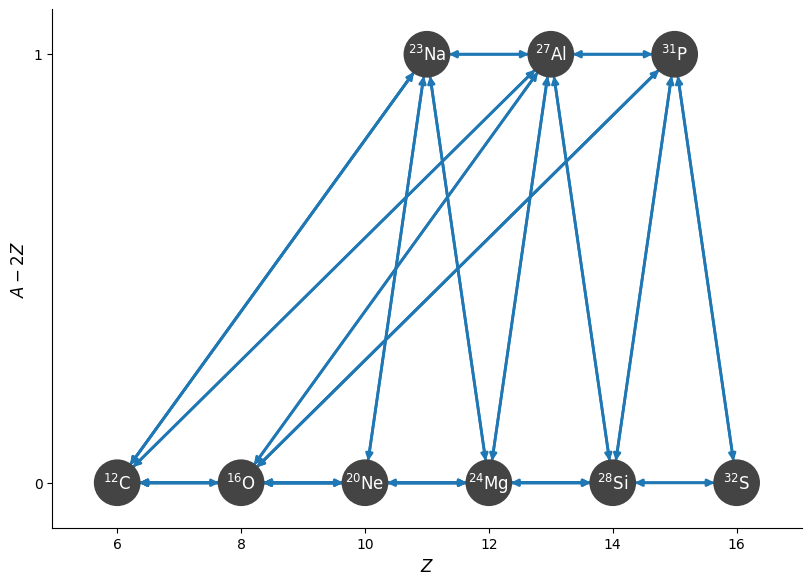

In [8]:
fig = net.plot(rotated=True)

Note that we left in the $(\alpha,\gamma)$ links between the odd-numbered nuclei that we will approximate out (e.g., ${}^{23}\mathrm{Na}(\alpha,\gamma){}^{27}\mathrm{Al}$).  These links will not be present in the approximate network we consider next.

Finally, we'll write out the network and then reimport it.

We'll integrate it, starting with a mix of half carbon / half oxygen.

In [9]:
rho = 1.e7
T = 3e9

comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("c12")] = 0.5
comp.X[pyna.Nucleus("o16")] = 0.5
Y0 = comp.get_molar_array()

In [10]:
tmax = 100.0

In [11]:
sol_full = net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


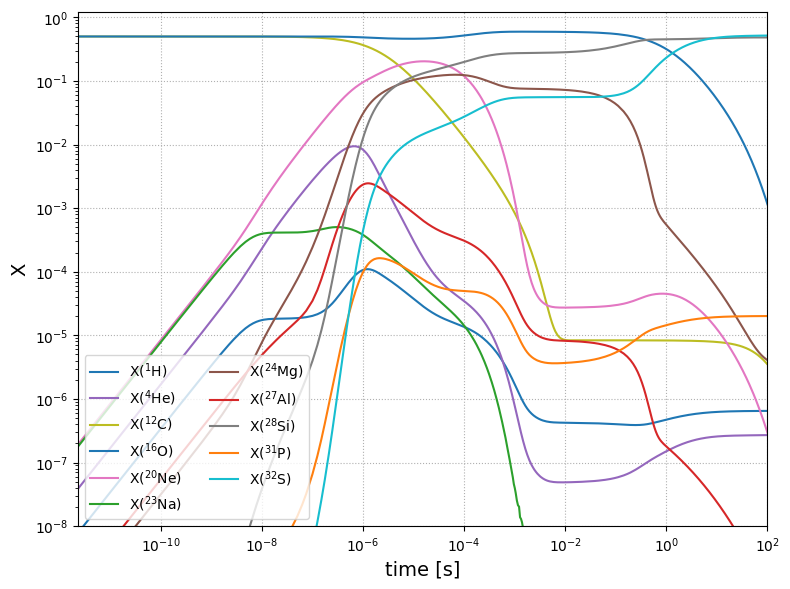

In [12]:
fig = sol_full.plot_evolution(ymin=1.e-8)

## An approximate network

We'll start off with the list of rates from the network we just created, since this already rederived the reverse rates.

In [13]:
rates = net.get_rates()

In [14]:
crates = make_CO_approx_rates(rates, "C")

In [15]:
corates = make_CO_approx_rates(rates, "CO")

In [16]:
orates = make_CO_approx_rates(rates, "O")

and let's pull in the ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ and ${}^{16}\mathrm{O}(\alpha,\gamma){}^{20}\mathrm{Ne}$ rates

In [17]:
lib = pyna.Library(rates=rates)

In [18]:
c12ag = lib.get_rate_by_name("c12(a,g)o16")
c12ag_reverse = lib.get_rate_by_name("o16(g,a)c12")
o16ag = lib.get_rate_by_name("o16(a,g)ne20")
o16ag_reverse = lib.get_rate_by_name("ne20(g,a)o16")

In [19]:
anet = pyna.PythonNetwork(rates=crates+corates+orates+
                          [c12ag,c12ag_reverse,o16ag,o16ag_reverse])

In [20]:
anet.summary()

Network summary
---------------
  explicitly carried nuclei: 7
  approximated-out nuclei: 4
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 52

  rates explicitly connecting nuclei: 22
  hidden rates: 30

  reaclib rates: 17
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 18
  derived rates: 17
  modified rates: 0
  custom rates: 0


Notice that our approximate network has 4 fewer nuclei and only 22 rates directly connecting the nuclei, instead of 38.

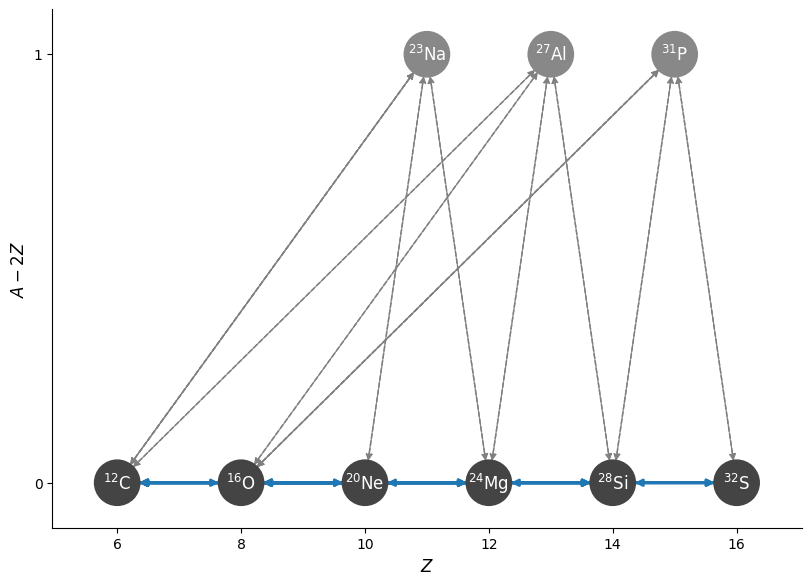

In [21]:
fig = anet.plot(rotated=True)

In [22]:
comp = pyna.Composition(anet.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("c12")] = 0.5
comp.X[pyna.Nucleus("o16")] = 0.5
Y0 = comp.get_molar_array()

In [23]:
sol_approx = anet.integrate_network(tmax, rho, T, Y0, rtol=1.e-6)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:407: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


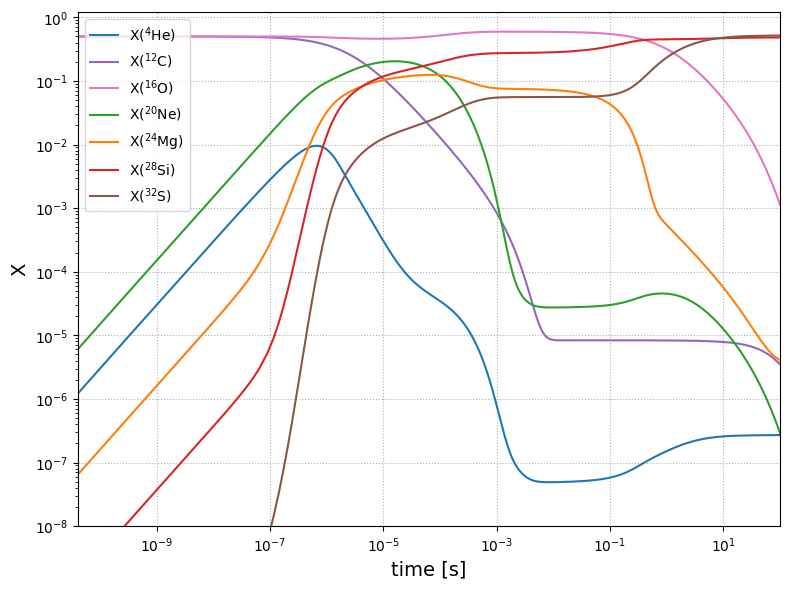

In [24]:
fig2 = sol_approx.plot_evolution(ymin=1.e-8)

## Comparing

Finally, we'll compare the two networks, by plotting them on the same axes.

In [25]:
import matplotlib.pyplot as plt

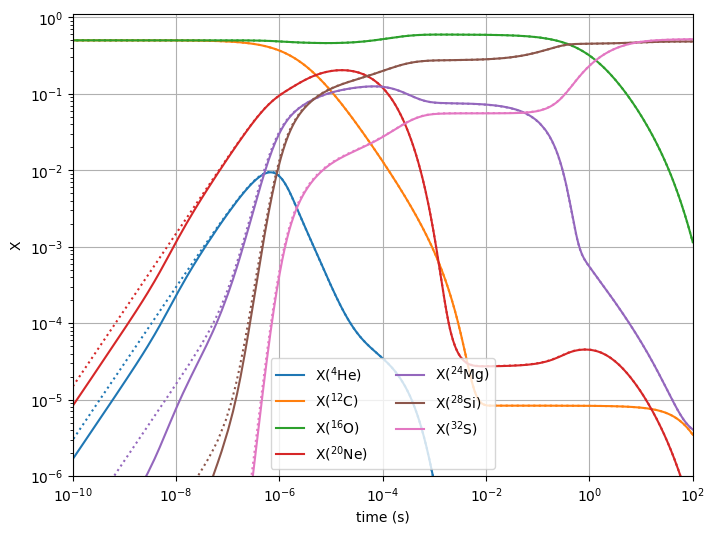

In [26]:
fig, ax = plt.subplots()

for i, nuc in enumerate(sol_approx.unique_nuclei):
    ax.loglog(sol_approx.t, sol_approx.X[i, :],
              linestyle=":", color=f"C{i}")    
    idx = sol_full.unique_nuclei.index(nuc)
    ax.loglog(sol_full.t, sol_full.X[idx, :],
              label=rf"X$({nuc.pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-10, 100)
fig.set_size_inches((8,6))
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend(ncol=2, loc=8)
ax.grid()